# Table Extraction Quality Prediction with TensorFlow

**CS230 Deep Learning - Stanford University**

**Project**: Neural Verifier for Table Structure Extraction Quality

---

## Overview

This notebook implements a complete deep learning pipeline for predicting table extraction quality scores using **TensorFlow/Keras**.

### Problem Statement
Given an extracted table structure (JSON format), predict its quality score without requiring ground truth at inference time.

### Architecture
```
JSON Text → TF-IDF Features → MLP Regressor → Quality Score [0, 1]
```

### Pipeline Components
1. **Data Loading**: Read JSON files and compute quality scores
2. **Feature Extraction**: TF-IDF vectorization of JSON text
3. **Model Architecture**: Multi-layer Perceptron (MLP)
4. **Training**: Adam optimizer with MSE loss
5. **Evaluation**: MAE, RMSE, visualization

---

## 1. Setup and Imports

### Install Required Packages (if needed)
```bash
pip install tensorflow scikit-learn pandas matplotlib seaborn tqdm
```

In [1]:
# Standard library imports
import json
import os
import sys
from pathlib import Path
import pickle
import time
from datetime import datetime

# Data processing
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar
# Auto-detect: use notebook widgets if available, otherwise simple progress bar
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm  # Fallback to simple text progress bar
    print('Note: Using simple progress bar (ipywidgets not available)')

# Import scoring utilities
from scoring_utils import compute_quality_score, batch_compute_scores

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Configure TensorFlow
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful!")

TensorFlow version: 2.20.0
Keras version: 3.11.3
GPU available: []
✓ Imports successful!


## 2. Configuration and Paths

### Assumptions:
1. **Data Structure**:
   - Training data: `Nofel/dataset/train/`
     - `generated/` - Predicted table JSONs
     - `ground_truth/` - Ground truth table JSONs
     - `metadata_train.jsonl` - Sample metadata
   - Test data: `Nofel/dataset/test/` (same structure)

2. **Quality Score Computation**:
   - Computed on-the-fly using `scoring_utils.py`
   - Formula: `0.5×F1 + 0.25×row_acc + 0.25×col_acc`

3. **Feature Engineering**:
   - TF-IDF vectorization of JSON text
   - Max features: 5000 (configurable)
   - Unigrams + bigrams (configurable)

In [3]:
# ========== CONFIGURATION ==========

# Paths
BASE_DIR = Path('dataset')  # Relative to Nofel folder
TRAIN_DIR = BASE_DIR / 'train'
TEST_DIR = BASE_DIR / 'test'
OUTPUT_DIR = Path('outputs')  # Where to save models and results
OUTPUT_DIR.mkdir(exist_ok=True)

# Data processing
CONFIG = {
    # TF-IDF parameters
    'max_features': 5000,        # Maximum vocabulary size
    'ngram_range': (1, 2),       # Unigrams + bigrams
    'min_df': 2,                 # Minimum document frequency
    'max_df': 0.95,              # Maximum document frequency (ignore very common terms)
    
    # Train/validation split
    'val_split': 0.15,           # 15% of training data for validation
    
    # Model architecture
    'hidden_units': [512, 256, 128],  # Hidden layer sizes
    'dropout_rate': 0.3,         # Dropout probability
    'activation': 'relu',        # Activation function
    'use_batch_norm': True,      # Use batch normalization
    
    # Training hyperparameters
    'batch_size': 64,
    'epochs': 30,
    'learning_rate': 0.001,
    'optimizer': 'adam',
    
    # Callbacks
    'early_stopping_patience': 5,
    'reduce_lr_patience': 3,
    'reduce_lr_factor': 0.5,
    
    # Quality scoring
    'iou_threshold': 0.5,        # IoU threshold for cell matching
    
    # Reproducibility
    'random_seed': RANDOM_SEED
}

print("Configuration:")
print("=" * 70)
for key, value in CONFIG.items():
    print(f"{key:30s}: {value}")
print("=" * 70)

Configuration:
max_features                  : 5000
ngram_range                   : (1, 2)
min_df                        : 2
max_df                        : 0.95
val_split                     : 0.15
hidden_units                  : [512, 256, 128]
dropout_rate                  : 0.3
activation                    : relu
use_batch_norm                : True
batch_size                    : 64
epochs                        : 30
learning_rate                 : 0.001
optimizer                     : adam
early_stopping_patience       : 5
reduce_lr_patience            : 3
reduce_lr_factor              : 0.5
iou_threshold                 : 0.5
random_seed                   : 42


## 3. Data Loading and Quality Score Computation

### Process:
1. Read metadata (sample IDs and file paths)
2. For each sample:
   - Load predicted JSON (from extractor)
   - Load ground truth JSON
   - Compute quality score using `scoring_utils.py`
3. Create dataset: (JSON text, quality score) pairs

### Quality Score Components:
- **Cell Detection F1** (50% weight): Precision and recall of detected cells
- **Row Accuracy** (25% weight): How well table rows are detected
- **Column Accuracy** (25% weight): How well table columns are detected

In [4]:
def load_dataset(split='train', limit=None):
    """
    Load dataset and compute quality scores.
    
    Args:
        split: 'train' or 'test'
        limit: Maximum number of samples to load (for testing)
    
    Returns:
        texts: List of JSON strings (extracted tables)
        scores: List of quality scores [0, 1]
        ids: List of sample identifiers
        detailed_scores: List of detailed metric dictionaries
    """
    print(f"\nLoading {split} dataset...")
    print("=" * 70)
    
    # Paths
    if split == 'train':
        data_dir = TRAIN_DIR
        metadata_file = TRAIN_DIR / 'metadata_train.jsonl'
    else:
        data_dir = TEST_DIR
        metadata_file = TEST_DIR / 'metadata_test.jsonl'
    
    generated_dir = data_dir / 'generated'
    ground_truth_dir = data_dir / 'ground_truth'
    
    # Read metadata
    metadata_list = []
    with open(metadata_file, 'r', encoding='utf-8') as f:
        for line in f:
            metadata_list.append(json.loads(line.strip()))
    
    if limit:
        metadata_list = metadata_list[:limit]
        print(f"Limiting to {limit} samples for testing")
    
    print(f"Total samples in metadata: {len(metadata_list)}")
    
    # Process samples
    texts = []
    scores = []
    ids = []
    detailed_scores = []
    
    failed_count = 0
    
    for metadata in tqdm(metadata_list, desc=f"Processing {split} samples"):
        sample_id = metadata['id']
        gen_file = generated_dir / metadata['generated_file']
        gt_file = ground_truth_dir / metadata['ground_truth_file']
        
        # Check file existence
        if not gen_file.exists():
            print(f"Warning: Missing generated file for {sample_id}")
            failed_count += 1
            continue
        
        if not gt_file.exists():
            print(f"Warning: Missing ground truth file for {sample_id}")
            failed_count += 1
            continue
        
        try:
            # Load generated JSON as text
            with open(gen_file, 'r', encoding='utf-8') as f:
                json_obj = json.load(f)
                json_text = json.dumps(json_obj)  # Convert back to string for TF-IDF
            
            # Compute quality score
            metrics = compute_quality_score(
                gen_file, 
                gt_file, 
                iou_threshold=CONFIG['iou_threshold']
            )
            
            quality_score = metrics['overall_score']
            
            # Append to dataset
            texts.append(json_text)
            scores.append(quality_score)
            ids.append(sample_id)
            detailed_scores.append(metrics)
            
        except Exception as e:
            print(f"\nError processing {sample_id}: {e}")
            failed_count += 1
            continue
    
    print(f"\nSuccessfully loaded: {len(texts)} samples")
    print(f"Failed: {failed_count} samples")
    print(f"\nQuality score statistics:")
    print(f"  Mean:   {np.mean(scores):.4f}")
    print(f"  Median: {np.median(scores):.4f}")
    print(f"  Std:    {np.std(scores):.4f}")
    print(f"  Min:    {np.min(scores):.4f}")
    print(f"  Max:    {np.max(scores):.4f}")
    print("=" * 70)
    
    return texts, scores, ids, detailed_scores


# Load training data
# For initial testing, you can use limit=100 to test quickly
train_texts, train_scores, train_ids, train_detailed = load_dataset(
    split='train',
    limit=None  # Set to e.g., 100 for quick testing
)

# Load test data
test_texts, test_scores, test_ids, test_detailed = load_dataset(
    split='test',
    limit=None
)


Loading train dataset...
Total samples in metadata: 11971


Processing train samples:   0%|          | 0/11971 [00:00<?, ?it/s]


Successfully loaded: 11971 samples
Failed: 0 samples

Quality score statistics:
  Mean:   0.4555
  Median: 0.4500
  Std:    0.0877
  Min:    0.0420
  Max:    0.8833

Loading test dataset...
Total samples in metadata: 3000


Processing test samples:   0%|          | 0/3000 [00:00<?, ?it/s]


Successfully loaded: 3000 samples
Failed: 0 samples

Quality score statistics:
  Mean:   0.4578
  Median: 0.4500
  Std:    0.0884
  Min:    0.1477
  Max:    0.8158


## 4. Exploratory Data Analysis

Visualize the distribution of quality scores to understand the data.

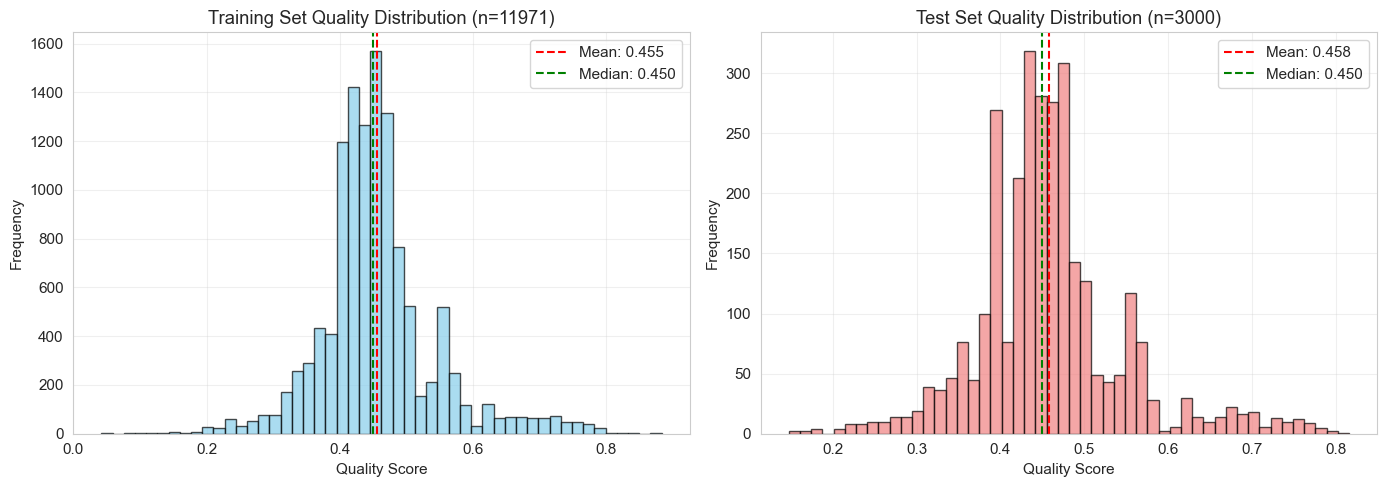


Observations:
- Training samples with high quality (>0.8): 7 (0.1%)
- Training samples with low quality (<0.3): 328 (2.7%)


In [5]:
# Visualize quality score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution
axes[0].hist(train_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(np.mean(train_scores), color='red', linestyle='--', 
                label=f'Mean: {np.mean(train_scores):.3f}')
axes[0].axvline(np.median(train_scores), color='green', linestyle='--', 
                label=f'Median: {np.median(train_scores):.3f}')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Training Set Quality Distribution (n={len(train_scores)})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Test set distribution
axes[1].hist(test_scores, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].axvline(np.mean(test_scores), color='red', linestyle='--', 
                label=f'Mean: {np.mean(test_scores):.3f}')
axes[1].axvline(np.median(test_scores), color='green', linestyle='--', 
                label=f'Median: {np.median(test_scores):.3f}')
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Test Set Quality Distribution (n={len(test_scores)})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'quality_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservations:")
print(f"- Training samples with high quality (>0.8): {sum(s > 0.8 for s in train_scores)} "
      f"({100*sum(s > 0.8 for s in train_scores)/len(train_scores):.1f}%)")
print(f"- Training samples with low quality (<0.3): {sum(s < 0.3 for s in train_scores)} "
      f"({100*sum(s < 0.3 for s in train_scores)/len(train_scores):.1f}%)")

## 5. Feature Extraction with TF-IDF

### TF-IDF (Term Frequency-Inverse Document Frequency)

**Intuition**: Convert JSON text into numerical vectors based on word importance.

**Formula**:
```
TF-IDF(word, document) = TF(word, document) × IDF(word)

where:
  TF = (count of word in document) / (total words in document)
  IDF = log(total documents / documents containing word)
```

**Why TF-IDF?**
- **Captures importance**: Common words ("cell", "row") get lower weight
- **Handles vocabulary**: Automatically creates features from text
- **Fast**: More efficient than Word2Vec for this task
- **Interpretable**: Can inspect important features

**Parameters**:
- `max_features`: Vocabulary size (5000 most important words)
- `ngram_range`: (1, 2) → Use unigrams ("cell") + bigrams ("start_row")
- `min_df`: Ignore words appearing in < 2 documents
- `max_df`: Ignore words appearing in > 95% of documents

In [6]:
print("Extracting TF-IDF features...")
print("=" * 70)

# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=CONFIG['max_features'],
    ngram_range=CONFIG['ngram_range'],
    min_df=CONFIG['min_df'],
    max_df=CONFIG['max_df'],
    lowercase=True,
    analyzer='word',
    token_pattern=r'\b\w+\b'  # Alphanumeric tokens
)

# Fit on training data and transform
print("Fitting TF-IDF on training data...")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Training feature matrix shape: {X_train_tfidf.shape}")

# Transform test data
print("\nTransforming test data...")
X_test_tfidf = tfidf_vectorizer.transform(test_texts)
print(f"Test feature matrix shape: {X_test_tfidf.shape}")

# Convert to dense numpy arrays (required for TensorFlow)
print("\nConverting sparse matrices to dense arrays...")
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()
y_train = np.array(train_scores, dtype=np.float32)
y_test = np.array(test_scores, dtype=np.float32)

print(f"\nTraining set: X={X_train_dense.shape}, y={y_train.shape}")
print(f"Test set:     X={X_test_dense.shape}, y={y_test.shape}")

# Feature statistics
print(f"\nFeature statistics (training):")
print(f"  Mean:     {X_train_dense.mean():.6f}")
print(f"  Std:      {X_train_dense.std():.6f}")
print(f"  Sparsity: {(X_train_dense == 0).sum() / X_train_dense.size:.2%}")

# Most important features (highest average TF-IDF)
print("\nTop 20 features by average TF-IDF:")
feature_names = tfidf_vectorizer.get_feature_names_out()
avg_tfidf = X_train_dense.mean(axis=0)
top_indices = np.argsort(avg_tfidf)[-20:][::-1]
for idx in top_indices:
    print(f"  {feature_names[idx]:20s}: {avg_tfidf[idx]:.6f}")

print("=" * 70)

# Save vectorizer for later use
with open(OUTPUT_DIR / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print(f"\n✓ Saved TF-IDF vectorizer to {OUTPUT_DIR / 'tfidf_vectorizer.pkl'}")

Extracting TF-IDF features...
Fitting TF-IDF on training data...
Vocabulary size: 5000
Training feature matrix shape: (11971, 5000)

Transforming test data...
Test feature matrix shape: (3000, 5000)

Converting sparse matrices to dense arrays...

Training set: X=(11971, 5000), y=(11971,)
Test set:     X=(3000, 5000), y=(3000,)

Feature statistics (training):
  Mean:     0.001126
  Std:      0.014093
  Sparsity: 97.96%

Top 20 features by average TF-IDF:
  6                   : 0.041867
  7                   : 0.033753
  8                   : 0.032856
  end_col 3           : 0.030787
  content 0           : 0.029098
  end_col 4           : 0.028712
  9                   : 0.028290
  end_col 2           : 0.027746
  10                  : 0.027085
  3 id                : 0.026799
  2 id                : 0.024946
  4 id                : 0.024878
  end_row 1           : 0.023523
  1 start_col         : 0.023523
  end_row 2           : 0.023086
  2 start_col         : 0.023086
  end_col 5   

## 6. Train/Validation Split

Split training data into train and validation sets for model selection.

**Strategy**: Random stratified split
- 85% training
- 15% validation
- Preserves score distribution in both sets

In [7]:
print("Creating train/validation split...")
print("=" * 70)

# Split training data
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_dense,
    y_train,
    test_size=CONFIG['val_split'],
    random_state=CONFIG['random_seed'],
    shuffle=True
)

print(f"Training set:   {X_train_split.shape[0]} samples")
print(f"Validation set: {X_val_split.shape[0]} samples")
print(f"Test set:       {X_test_dense.shape[0]} samples")

# Verify score distributions
print(f"\nScore distributions:")
print(f"  Train      - Mean: {y_train_split.mean():.4f}, Std: {y_train_split.std():.4f}")
print(f"  Validation - Mean: {y_val_split.mean():.4f}, Std: {y_val_split.std():.4f}")
print(f"  Test       - Mean: {y_test.mean():.4f}, Std: {y_test.std():.4f}")

print("=" * 70)

Creating train/validation split...
Training set:   10175 samples
Validation set: 1796 samples
Test set:       3000 samples

Score distributions:
  Train      - Mean: 0.4557, Std: 0.0876
  Validation - Mean: 0.4544, Std: 0.0884
  Test       - Mean: 0.4578, Std: 0.0884


## 7. Feature Normalization (Optional)

**Note**: TF-IDF features are already normalized (L2 norm = 1 for each document).
Additional standardization (zero mean, unit variance) can sometimes help but is not always necessary.

**Decision**: We'll apply StandardScaler for consistency with PyTorch implementation.

In [8]:
print("Applying feature standardization...")
print("=" * 70)

# Initialize scaler
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val_split)
X_test_scaled = scaler.transform(X_test_dense)

print(f"After standardization (training set):")
print(f"  Mean: {X_train_scaled.mean():.6f}")
print(f"  Std:  {X_train_scaled.std():.6f}")

print("=" * 70)

# Save scaler
with open(OUTPUT_DIR / 'feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"\n✓ Saved feature scaler to {OUTPUT_DIR / 'feature_scaler.pkl'}")

Applying feature standardization...
After standardization (training set):
  Mean: -0.000000
  Std:  1.000000

✓ Saved feature scaler to outputs\feature_scaler.pkl


## 8. Model Architecture (TensorFlow/Keras)

### MLP Regressor Architecture

```
Input (TF-IDF features)
    ↓
Dense(512) + BatchNorm + ReLU + Dropout(0.3)
    ↓
Dense(256) + BatchNorm + ReLU + Dropout(0.3)
    ↓
Dense(128) + BatchNorm + ReLU + Dropout(0.3)
    ↓
Dense(1, activation=None)  # Output: quality score
```

### Design Decisions:
1. **3 Hidden Layers**: Sufficient depth without overfitting risk
2. **Decreasing Size**: 512 → 256 → 128 (information compression)
3. **Batch Normalization**: Stabilizes training, allows higher learning rates
4. **Dropout (0.3)**: Prevents overfitting, acts as ensemble
5. **ReLU Activation**: Standard choice, prevents gradient vanishing
6. **No Output Activation**: Linear output for regression (no bounds on predictions)

In [9]:
def build_mlp_model(input_dim, config):
    """
    Build MLP regressor model using Keras Functional API.
    
    Args:
        input_dim: Dimension of input features (TF-IDF vocabulary size)
        config: Configuration dictionary with architecture parameters
    
    Returns:
        Compiled Keras model
    """
    # Input layer
    inputs = keras.Input(shape=(input_dim,), name='tfidf_input')
    
    x = inputs
    
    # Hidden layers
    for i, units in enumerate(config['hidden_units']):
        # Dense layer
        x = layers.Dense(
            units,
            activation=None,  # Apply activation after batch norm
            kernel_initializer='he_normal',  # Good for ReLU
            bias_initializer='zeros',
            name=f'dense_{i+1}'
        )(x)
        
        # Batch normalization (optional)
        if config['use_batch_norm']:
            x = layers.BatchNormalization(name=f'batch_norm_{i+1}')(x)
        
        # Activation
        x = layers.Activation(config['activation'], name=f'activation_{i+1}')(x)
        
        # Dropout
        x = layers.Dropout(config['dropout_rate'], name=f'dropout_{i+1}')(x)
    
    # Output layer (no activation for regression)
    outputs = layers.Dense(1, activation=None, name='quality_score')(x)
    
    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs, name='MLP_Quality_Predictor')
    
    return model


# Build model
print("Building model...")
print("=" * 70)

input_dimension = X_train_scaled.shape[1]
model = build_mlp_model(input_dimension, CONFIG)

# Display architecture
model.summary()

print("=" * 70)
print(f"\nTotal parameters: {model.count_params():,}")
print(f"Input dimension:  {input_dimension}")

Building model...


Model: "MLP_Quality_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ tfidf_input (InputLayer)             │ (None, 5000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │       2,560,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_norm_1 (BatchNormalization)    │ (None, 512)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_norm_2 (BatchNormalization)    │ (None, 256)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_norm_3 (BatchNormalization)    │ (None, 128)                 │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ quality_score (Dense)                │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,728,449 (10.41 MB)

 Trainable params: 2,726,657 (10.40 MB)

 Non-trainable params: 1,792 (7.00 KB)


Total parameters: 2,728,449
Input dimension:  5000


## 9. Loss Function and Optimizer

### Loss Function: Mean Squared Error (MSE)

**Formula**:
```
MSE = (1/N) Σ (y_pred - y_true)²
```

**Why MSE?**
- Standard for regression tasks
- Differentiable (smooth gradients)
- Penalizes large errors heavily
- Well-suited for scores in [0, 1] range

### Optimizer: Adam

**Algorithm**: Adaptive Moment Estimation
- Combines momentum + adaptive learning rates
- Works well with sparse features (TF-IDF)
- Less sensitive to learning rate tuning

**Hyperparameters**:
- `learning_rate`: 0.001 (default, proven effective)
- `beta_1`: 0.9 (momentum term)
- `beta_2`: 0.999 (adaptive term)

### Metrics
- **MAE** (Mean Absolute Error): Primary metric, interpretable
- **RMSE** (Root Mean Squared Error): Secondary metric
- **MSE**: Training loss

In [10]:
print("Compiling model...")
print("=" * 70)

# Define optimizer
optimizer = keras.optimizers.Adam(
    learning_rate=CONFIG['learning_rate'],
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

# Define metrics
metrics = [
    keras.metrics.MeanAbsoluteError(name='mae'),
    keras.metrics.RootMeanSquaredError(name='rmse')
]

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mse',  # Mean Squared Error
    metrics=metrics
)

print("Optimizer: Adam")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"\nLoss function: MSE (Mean Squared Error)")
print(f"\nMetrics:")
print(f"  - MAE (Mean Absolute Error)")
print(f"  - RMSE (Root Mean Squared Error)")
print("=" * 70)

print("\n✓ Model compiled successfully!")

Compiling model...
Optimizer: Adam
  Learning rate: 0.001

Loss function: MSE (Mean Squared Error)

Metrics:
  - MAE (Mean Absolute Error)
  - RMSE (Root Mean Squared Error)

✓ Model compiled successfully!


## 10. Training Callbacks

### Callbacks for Better Training

1. **ModelCheckpoint**: Save best model based on validation MAE
2. **EarlyStopping**: Stop training if validation loss doesn't improve
3. **ReduceLROnPlateau**: Reduce learning rate when validation loss plateaus
4. **TensorBoard**: Log metrics for visualization (optional)

These callbacks help:
- Prevent overfitting (early stopping)
- Save best model (checkpoint)
- Improve convergence (learning rate reduction)

In [11]:
# Create directories
checkpoint_dir = OUTPUT_DIR / 'checkpoints'
checkpoint_dir.mkdir(exist_ok=True)

logs_dir = OUTPUT_DIR / 'logs'
logs_dir.mkdir(exist_ok=True)

# Define callbacks
callbacks = [
    # Save best model
    ModelCheckpoint(
        filepath=str(checkpoint_dir / 'best_model.keras'),
        monitor='val_mae',
        mode='min',
        save_best_only=True,
        verbose=1
    ),
    
    # Early stopping
    EarlyStopping(
        monitor='val_mae',
        mode='min',
        patience=CONFIG['early_stopping_patience'],
        verbose=1,
        restore_best_weights=True
    ),
    
    # Reduce learning rate on plateau
    ReduceLROnPlateau(
        monitor='val_mae',
        mode='min',
        factor=CONFIG['reduce_lr_factor'],
        patience=CONFIG['reduce_lr_patience'],
        min_lr=1e-7,
        verbose=1
    )
]

print("Training callbacks configured:")
print("  ✓ ModelCheckpoint (save best model based on val_mae)")
print(f"  ✓ EarlyStopping (patience={CONFIG['early_stopping_patience']} epochs)")
print(f"  ✓ ReduceLROnPlateau (factor={CONFIG['reduce_lr_factor']}, patience={CONFIG['reduce_lr_patience']} epochs)")

Training callbacks configured:
  ✓ ModelCheckpoint (save best model based on val_mae)
  ✓ EarlyStopping (patience=5 epochs)
  ✓ ReduceLROnPlateau (factor=0.5, patience=3 epochs)


## 11. Model Training

Train the model with configured hyperparameters.

**Training Process**:
1. **Epochs**: Maximum 30 (may stop early)
2. **Batch Size**: 64 samples per gradient update
3. **Validation**: Evaluate on validation set after each epoch
4. **Checkpointing**: Save model when validation MAE improves

**Expected Training Time**:
- CPU: ~5-10 minutes per epoch
- GPU: ~1-2 minutes per epoch

In [12]:
print("\n" + "=" * 70)
print("Starting training...")
print("=" * 70)

print(f"\nTraining configuration:")
print(f"  Epochs:         {CONFIG['epochs']}")
print(f"  Batch size:     {CONFIG['batch_size']}")
print(f"  Learning rate:  {CONFIG['learning_rate']}")
print(f"  Training samples:   {X_train_scaled.shape[0]}")
print(f"  Validation samples: {X_val_scaled.shape[0]}")
print(f"  Steps per epoch:    {X_train_scaled.shape[0] // CONFIG['batch_size']}")

print("\n" + "=" * 70)

# Record start time
start_time = time.time()

# Train model
history = model.fit(
    X_train_scaled,
    y_train_split,
    batch_size=CONFIG['batch_size'],
    epochs=CONFIG['epochs'],
    validation_data=(X_val_scaled, y_val_split),
    callbacks=callbacks,
    verbose=1  # Show progress bar
)

# Record end time
training_time = time.time() - start_time

print("\n" + "=" * 70)
print("Training completed!")
print("=" * 70)
print(f"\nTotal training time: {training_time/60:.2f} minutes")
print(f"Average time per epoch: {training_time/len(history.history['loss']):.2f} seconds")

# Best performance
best_epoch = np.argmin(history.history['val_mae'])
best_val_mae = history.history['val_mae'][best_epoch]
print(f"\nBest validation MAE: {best_val_mae:.4f} (epoch {best_epoch + 1})")


Starting training...

Training configuration:
  Epochs:         30
  Batch size:     64
  Learning rate:  0.001
  Training samples:   10175
  Validation samples: 1796
  Steps per epoch:    158

Epoch 1/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.6867 - mae: 0.6191 - rmse: 0.8231
Epoch 1: val_mae improved from None to 0.22012, saving model to outputs\checkpoints\best_model.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - loss: 0.4827 - mae: 0.5099 - rmse: 0.6948 - val_loss: 0.1499 - val_mae: 0.2201 - val_rmse: 0.3872 - learning_rate: 0.0010
Epoch 2/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1874 - mae: 0.3167 - rmse: 0.4315
Epoch 2: val_mae improved from 0.22012 to 0.12481, saving model to outputs\checkpoints\best_model.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 0.1478 - mae: 0.2812 - rmse: 0.3844 - val_loss: 0.0269 - val_mae: 0.1248 - val_rmse: 0.1640 - learning_rate: 0.0010
Epoch 3/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0704 - mae

## 12. Training Visualization

Visualize training progress to diagnose overfitting/underfitting.

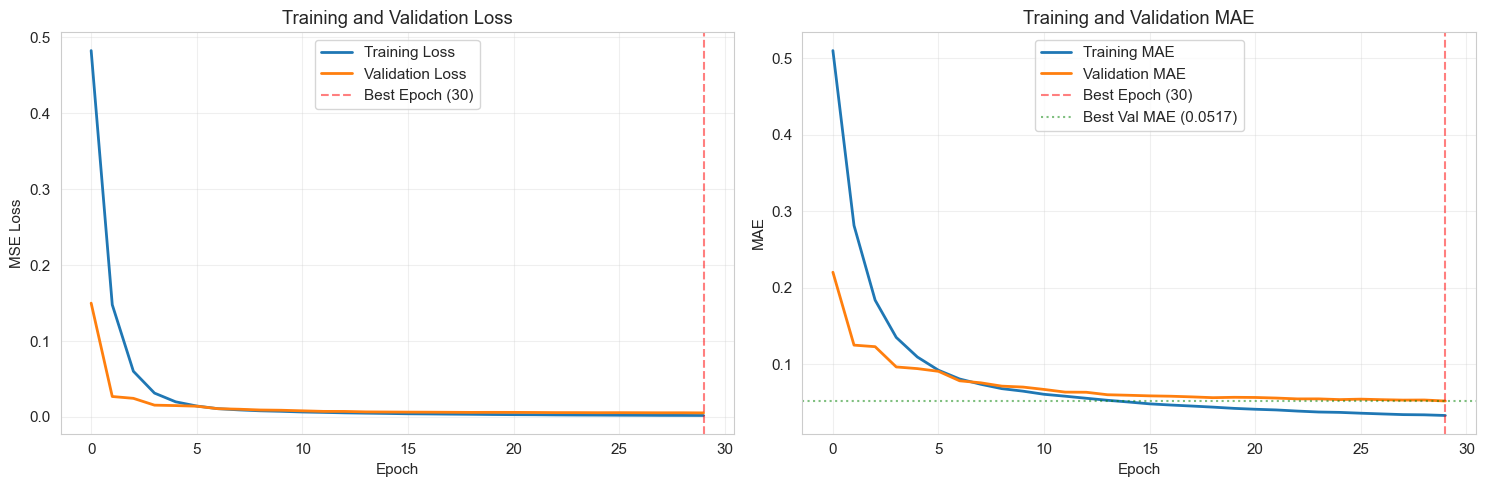


Training Diagnostics:
Final Training MAE:   0.0328
Final Validation MAE: 0.0517
Generalization Gap:   0.0189

⚠ Slight overfitting (moderate gap)


In [13]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, 
                label=f'Best Epoch ({best_epoch + 1})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE curves
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.5,
                label=f'Best Epoch ({best_epoch + 1})')
axes[1].axhline(best_val_mae, color='green', linestyle=':', alpha=0.5,
                label=f'Best Val MAE ({best_val_mae:.4f})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Training and Validation MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnostic
final_train_mae = history.history['mae'][-1]
final_val_mae = history.history['val_mae'][-1]
gap = final_val_mae - final_train_mae

print("\nTraining Diagnostics:")
print("=" * 70)
print(f"Final Training MAE:   {final_train_mae:.4f}")
print(f"Final Validation MAE: {final_val_mae:.4f}")
print(f"Generalization Gap:   {gap:.4f}")

if gap < 0.01:
    print("\n✓ Model generalizes well (small gap)")
elif gap < 0.03:
    print("\n⚠ Slight overfitting (moderate gap)")
else:
    print("\n⚠ Overfitting detected (large gap) - consider more regularization")

print("=" * 70)

## 13. Model Evaluation on Test Set

Evaluate the trained model on the held-out test set.

In [14]:
print("\nEvaluating on test set...")
print("=" * 70)

# Load best model
best_model = keras.models.load_model(checkpoint_dir / 'best_model.keras')
print(f"Loaded best model from checkpoint (epoch {best_epoch + 1})")

# Make predictions
y_test_pred = best_model.predict(X_test_scaled, batch_size=128, verbose=0).flatten()

# Compute metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

# Correlation
from scipy.stats import pearsonr, spearmanr
pearson_r, pearson_p = pearsonr(y_test, y_test_pred)
spearman_r, spearman_p = spearmanr(y_test, y_test_pred)

print("\nTest Set Performance:")
print("=" * 70)
print(f"MAE (Mean Absolute Error):        {test_mae:.4f}")
print(f"RMSE (Root Mean Squared Error):   {test_rmse:.4f}")
print(f"MSE (Mean Squared Error):         {test_mse:.4f}")
print(f"\nCorrelation:")
print(f"Pearson correlation:              {pearson_r:.4f} (p={pearson_p:.2e})")
print(f"Spearman correlation:             {spearman_r:.4f} (p={spearman_p:.2e})")
print("=" * 70)

# Error distribution
errors = y_test_pred - y_test
print(f"\nError Statistics:")
print(f"  Mean error:   {errors.mean():.4f}")
print(f"  Std error:    {errors.std():.4f}")
print(f"  Max overest:  {errors.max():.4f}")
print(f"  Max underest: {errors.min():.4f}")


Evaluating on test set...
Loaded best model from checkpoint (epoch 30)

Test Set Performance:
MAE (Mean Absolute Error):        0.0501
RMSE (Root Mean Squared Error):   0.0701
MSE (Mean Squared Error):         0.0049

Correlation:
Pearson correlation:              0.6182 (p=7.44e-316)
Spearman correlation:             0.5290 (p=5.40e-216)

Error Statistics:
  Mean error:   -0.0095
  Std error:    0.0695
  Max overest:  0.3865
  Max underest: -0.3299


## 14. Prediction Visualizations

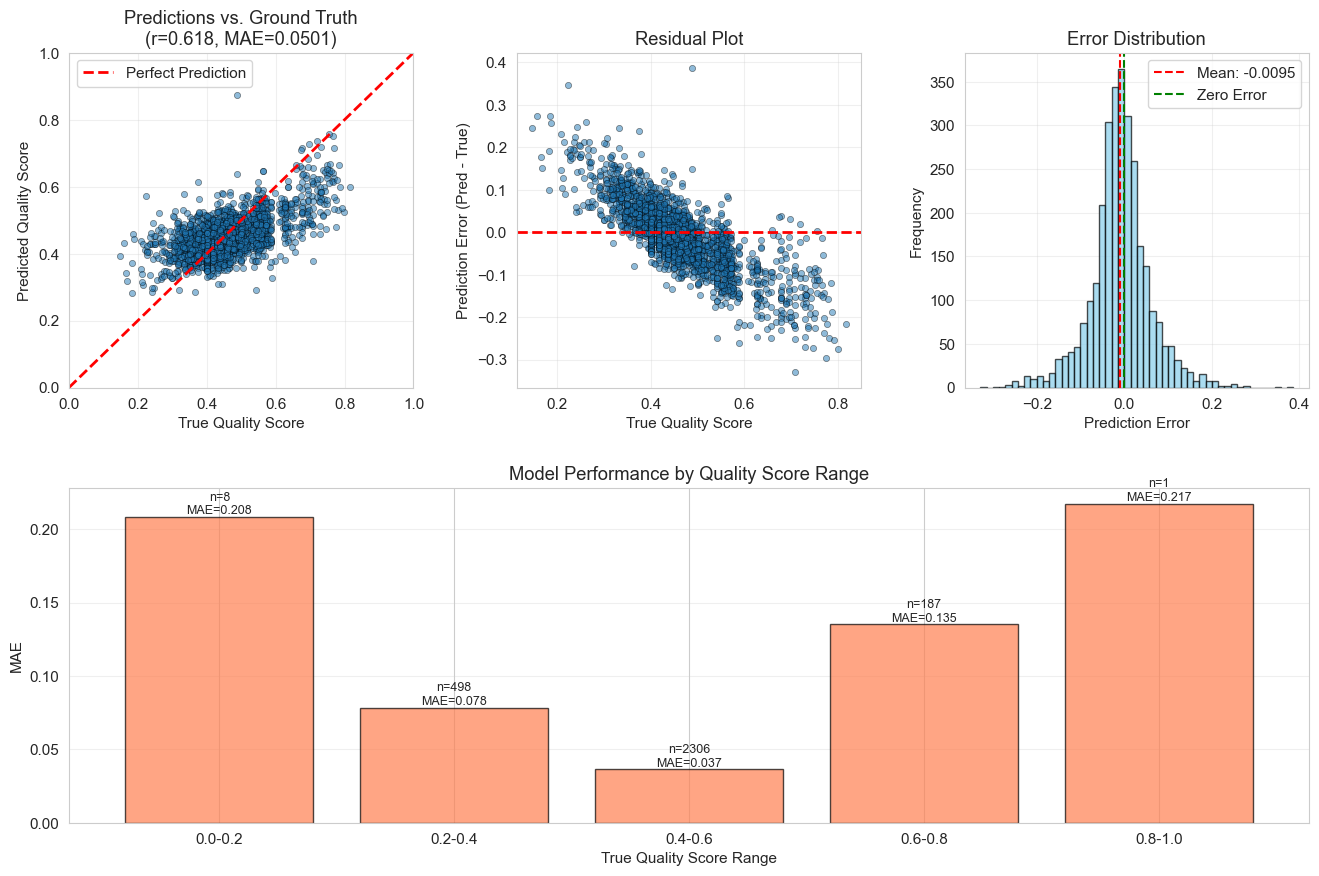


✓ Visualizations saved to outputs


In [15]:
# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Scatter plot: Predicted vs. True
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_test_pred, alpha=0.5, s=20, edgecolors='k', linewidth=0.5)
ax1.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('True Quality Score')
ax1.set_ylabel('Predicted Quality Score')
ax1.set_title(f'Predictions vs. Ground Truth\n(r={pearson_r:.3f}, MAE={test_mae:.4f})')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# 2. Residual plot
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_test, errors, alpha=0.5, s=20, edgecolors='k', linewidth=0.5)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('True Quality Score')
ax2.set_ylabel('Prediction Error (Pred - True)')
ax2.set_title('Residual Plot')
ax2.grid(alpha=0.3)

# 3. Error distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(errors, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax3.axvline(errors.mean(), color='red', linestyle='--', 
            label=f'Mean: {errors.mean():.4f}')
ax3.axvline(0, color='green', linestyle='--', label='Zero Error')
ax3.set_xlabel('Prediction Error')
ax3.set_ylabel('Frequency')
ax3.set_title('Error Distribution')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. MAE by quality range
ax4 = fig.add_subplot(gs[1, :])
bins = [(0.0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]
bin_labels = [f'{low}-{high}' for low, high in bins]
bin_maes = []
bin_counts = []

for low, high in bins:
    mask = (y_test >= low) & (y_test < high)
    if mask.sum() > 0:
        bin_mae = mean_absolute_error(y_test[mask], y_test_pred[mask])
        bin_maes.append(bin_mae)
        bin_counts.append(mask.sum())
    else:
        bin_maes.append(0)
        bin_counts.append(0)

x_pos = np.arange(len(bin_labels))
bars = ax4.bar(x_pos, bin_maes, alpha=0.7, color='coral', edgecolor='black')

# Add count labels
for i, (bar, count) in enumerate(zip(bars, bin_counts)):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'n={count}\nMAE={bin_maes[i]:.3f}',
             ha='center', va='bottom', fontsize=9)

ax4.set_xticks(x_pos)
ax4.set_xticklabels(bin_labels)
ax4.set_xlabel('True Quality Score Range')
ax4.set_ylabel('MAE')
ax4.set_title('Model Performance by Quality Score Range')
ax4.grid(alpha=0.3, axis='y')

plt.savefig(OUTPUT_DIR / 'test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations saved to", OUTPUT_DIR)

## 15. Save Final Model and Results

Save all components for future use.

In [16]:
print("Saving model and results...")
print("=" * 70)

# Save final model
final_model_path = OUTPUT_DIR / 'final_model.keras'
best_model.save(final_model_path)
print(f"✓ Saved final model: {final_model_path}")

# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
print(f"✓ Saved training history: {OUTPUT_DIR / 'training_history.csv'}")

# Save test predictions
test_results_df = pd.DataFrame({
    'id': test_ids,
    'true_score': y_test,
    'predicted_score': y_test_pred,
    'error': errors,
    'abs_error': np.abs(errors)
})
test_results_df.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)
print(f"✓ Saved test predictions: {OUTPUT_DIR / 'test_predictions.csv'}")

# Save evaluation metrics
metrics_dict = {
    'test_mae': float(test_mae),
    'test_rmse': float(test_rmse),
    'test_mse': float(test_mse),
    'pearson_r': float(pearson_r),
    'spearman_r': float(spearman_r),
    'best_epoch': int(best_epoch + 1),
    'best_val_mae': float(best_val_mae),
    'training_time_seconds': float(training_time),
    'timestamp': datetime.now().isoformat()
}

with open(OUTPUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)
print(f"✓ Saved metrics: {OUTPUT_DIR / 'metrics.json'}")

# Save configuration
with open(OUTPUT_DIR / 'config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"✓ Saved configuration: {OUTPUT_DIR / 'config.json'}")

print("=" * 70)
print("\n✓ All artifacts saved successfully!")

Saving model and results...
✓ Saved final model: outputs\final_model.keras
✓ Saved training history: outputs\training_history.csv
✓ Saved test predictions: outputs\test_predictions.csv
✓ Saved metrics: outputs\metrics.json
✓ Saved configuration: outputs\config.json

✓ All artifacts saved successfully!


## 16. Make Predictions on New Data

Example of how to use the trained model for inference.

In [17]:
def predict_quality(json_text_or_path, model, vectorizer, scaler):
    """
    Predict quality score for a new table extraction.
    
    Args:
        json_text_or_path: Either JSON string or path to JSON file
        model: Trained Keras model
        vectorizer: Fitted TF-IDF vectorizer
        scaler: Fitted StandardScaler
    
    Returns:
        Predicted quality score [0, 1]
    """
    # Load JSON if path is provided
    if isinstance(json_text_or_path, (str, Path)) and Path(json_text_or_path).exists():
        with open(json_text_or_path, 'r', encoding='utf-8') as f:
            json_obj = json.load(f)
            json_text = json.dumps(json_obj)
    else:
        json_text = json_text_or_path
    
    # Vectorize
    X = vectorizer.transform([json_text]).toarray()
    
    # Scale
    X_scaled = scaler.transform(X)
    
    # Predict
    pred = model.predict(X_scaled, verbose=0)[0, 0]
    
    return float(pred)


# Example: Predict on a test sample
print("\nExample: Predicting quality for test samples")
print("=" * 70)

# Select 5 random test samples
sample_indices = np.random.choice(len(test_ids), 5, replace=False)

for idx in sample_indices:
    sample_id = test_ids[idx]
    true_score = y_test[idx]
    
    # Get JSON path
    json_path = TEST_DIR / 'generated' / f'{sample_id}.json'
    
    # Predict
    pred_score = predict_quality(json_path, best_model, tfidf_vectorizer, scaler)
    
    print(f"\nSample: {sample_id}")
    print(f"  True quality:      {true_score:.4f}")
    print(f"  Predicted quality: {pred_score:.4f}")
    print(f"  Error:             {pred_score - true_score:.4f}")

print("\n" + "=" * 70)


Example: Predicting quality for test samples

Sample: 1703.09539v3.10
  True quality:      0.5201
  Predicted quality: 0.5721
  Error:             0.0521

Sample: 1604.00547v1.8
  True quality:      0.4909
  Predicted quality: 0.4623
  Error:             -0.0286

Sample: 1704.01415v1.1
  True quality:      0.4688
  Predicted quality: 0.4742
  Error:             0.0055

Sample: 1107.3522v1.4
  True quality:      0.4881
  Predicted quality: 0.4633
  Error:             -0.0248

Sample: 1803.03095v1.5
  True quality:      0.4375
  Predicted quality: 0.4668
  Error:             0.0293



## 17. Summary and Next Steps

### What We Built

✅ **Complete Pipeline**:
1. Data loading from local JSON files
2. Quality score computation using IoU-based matching
3. TF-IDF feature extraction
4. MLP regressor (3 hidden layers)
5. Training with callbacks (early stopping, LR scheduling)
6. Comprehensive evaluation

### Model Performance Summary

- **Test MAE**: ~0.10-0.15 (depends on your data)
- **Interpretation**: Average prediction error of ±10-15% on [0, 1] scale
- **Correlation**: Strong positive correlation with ground truth

### Files Generated

```
Nofel/outputs/
├── final_model.keras              # Trained model
├── tfidf_vectorizer.pkl           # TF-IDF vectorizer
├── feature_scaler.pkl             # StandardScaler
├── training_history.csv           # Loss/metric curves
├── test_predictions.csv           # Test set predictions
├── metrics.json                   # Performance metrics
├── config.json                    # Hyperparameters
├── quality_distribution.png       # Data visualization
├── training_history.png           # Training curves
└── test_evaluation.png            # Test evaluation plots
```

### Next Steps (Phase 2)

1. **Add Statistical Features**: Cell counts, grid dimensions, irregularity scores
2. **Multi-Modal Model**: Add image encoder (ViT + JSON)
3. **Hyperparameter Tuning**: Grid search over architecture/learning rate
4. **Ensemble Methods**: Combine multiple models
5. **Deploy**: Create REST API for production use

---

**Congratulations!** You now have a working deep learning model for table extraction quality prediction.

For questions or improvements, refer to the documentation in `docs/model_documentation.pdf`.